# CVPR Mid Term Project
# CRCCD_V1 — Colorectal Cancer Endoscopy Image Classification with a CNN 🔬

**Course:** Computer Vision and Pattern Recognition [A] — Summer 2025–2026

**Dataset:** CRCCD_V1 (Colorectal Cancer Classification and Detection)
- Kaggle mirror: https://www.kaggle.com/datasets/abpdash/crccd-v1
- Original source (Mendeley Data): https://data.mendeley.com/datasets/2pybr7f7yc/2
- **14 classes** of endoscopy images (anatomical landmarks + disease findings)
- Predefined split: **Train = 500 images/class (7,000)**, **Test = 125 images/class (1,750)** → **8,750 images total** ✅

**What this notebook does (as required by the midterm):**

1. Loads and explores the image dataset.
2. Builds a **basic CNN from scratch** (no pretrained models).
3. Trains the model **twice**:
   - **Round 1 — no augmentation, no dropout** → the model **overfits** (we show it with curves).
   - **Round 2 — simple data transformations (augmentation) + dropout** → **overfitting is controlled**.
4. Reports results: training vs validation **loss/accuracy curves**, **confusion matrix**, **classification report**, misclassified samples, and learned filters.

> Run the cells top to bottom (`Shift + Enter`).
> If the dataset is on your local disk, just check the path in Section 3. If you run on Google Colab/Kaggle, use the `kagglehub` option in the same cell.

## 1. Setup and Imports

We import PyTorch and a few helpers, then pick a device (GPU if available, otherwise CPU) and fix random seeds so results are repeatable.

In [ ]:
# ============================================================
# 1. SETUP AND IMPORTS
# ============================================================

# Core PyTorch libraries
import torch                                  # main PyTorch package (tensors, GPU support)
import torch.nn as nn                         # neural network layers (Conv2d, Linear, ...)
import torch.nn.functional as F               # functions like relu()

# Data loading + image transforms
from torchvision import datasets, transforms  # ImageFolder + image preprocessing
from torch.utils.data import DataLoader, Subset  # batching + splitting helpers

# Plotting + utilities
import matplotlib.pyplot as plt               # for all plots/curves
import numpy as np                            # numerical helper functions
import os                                     # file/folder handling

# Use the GPU if available (much faster training). Otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Fix random seeds so the results are repeatable every run
torch.manual_seed(42)
np.random.seed(42)


Using device: cuda


## 2. Hyperparameters

All the important experiment settings in one cell.

In [ ]:
# ============================================================
# 2. IMPORTANT HYPERPARAMETERS
# ============================================================
# Keeping all the "knobs" of the experiment in one place makes
# it easy to change them later and re-run the notebook.

IMG_SIZE   = 128     # every image is resized to 128 x 128 before entering the CNN
BATCH_SIZE = 32      # number of images fed to the model at a time
LR         = 1e-3    # learning rate for the Adam optimizer
EPOCHS_R1  = 15      # epochs for Round 1 (no augmentation  -> shows overfitting)
EPOCHS_R2  = 30      # epochs for Round 2 (augmentation + dropout -> controls overfitting)


## 3. Dataset Setup and Exploration

The CRCCD_V1 zip is downloaded automatically from a shared Google Drive link
using `gdown` (~2 GB, one-time per Colab session). No Drive mounting needed.

The dataset already comes pre-split by its authors:

```
CRCCD_V1/
├── Train/    (14 class folders × 500 images = 7,000 images)
└── Test/     (14 class folders × 125 images = 1,750 images)
```

`ImageFolder` labels the images automatically from the folder names.


Extracting dataset ...
Extraction done.
Train folder: /content/crccd/CRCCD_V1/Train
Test  folder: /content/crccd/CRCCD_V1/Test
Number of classes : 14
Train images      : 7000
Test  images      : 1750
Total images      : 8750


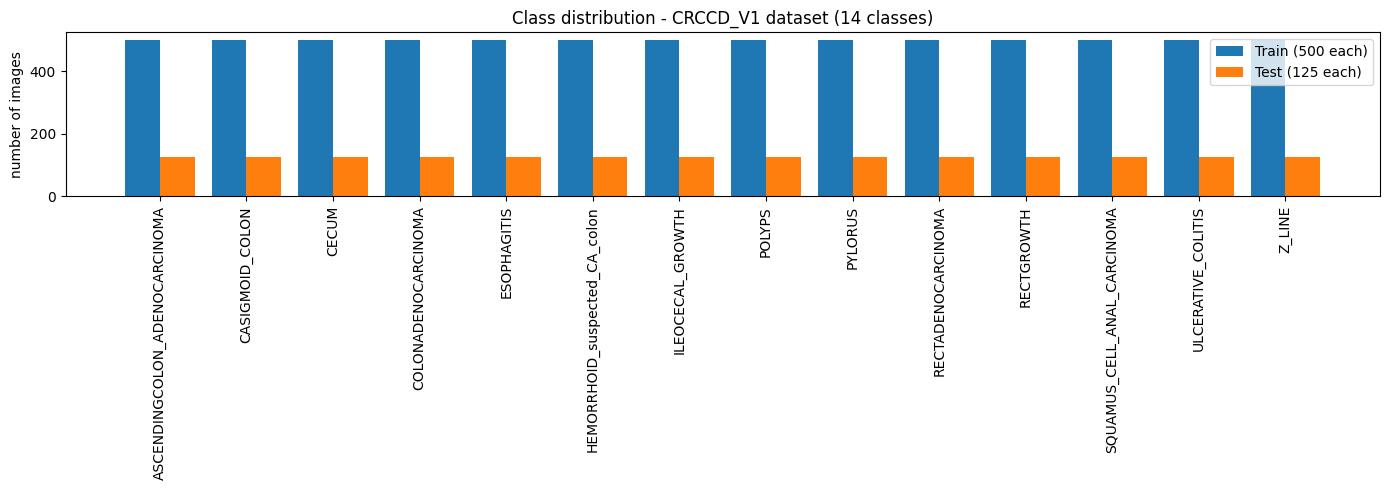

In [ ]:
# ============================================================
# 3. DATASET DOWNLOAD + PATH + CLASS DISTRIBUTION  (Google Colab)
# ============================================================
# Downloads CRCCD_V1.zip from a shared Google Drive link with gdown
# (no Drive mounting needed), unzips it, and finds Train/Test folders.

import os, zipfile

WORK_DIR = "/content/crccd"
os.makedirs(WORK_DIR, exist_ok=True)
ZIP_PATH = os.path.join(WORK_DIR, "CRCCD_V1.zip")

# Shared Google Drive file: CRCCD_V1.zip
# Google drive link: https://drive.google.com/file/d/1CD9_uf9k1zglI9_bmONxDv2bGCE2YLjz/view?usp=sharing
GDRIVE_FILE_ID = "1CD9_uf9k1zglI9_bmONxDv2bGCE2YLjz"

if not os.path.exists(ZIP_PATH):
    print("Downloading CRCCD_V1.zip (~2 GB) from Google Drive ... please wait")
    import gdown                      # pre-installed on Colab
    gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)
    print("Download complete.")

FLAG = os.path.join(WORK_DIR, "_extracted.flag")
if not os.path.exists(FLAG):
    print("Extracting dataset ...")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(WORK_DIR)
    open(FLAG, "w").close()
    print("Extraction done.")

# Find the folder that directly holds Train/ and Test/ subfolders
def find_split_root(root):
    for cur, subdirs, _ in os.walk(root):
        lower = [d.lower() for d in subdirs]
        if "train" in lower and "test" in lower:
            return cur
    return root

DATA_ROOT = find_split_root(WORK_DIR)
TRAIN_DIR = os.path.join(DATA_ROOT, "Train")
TEST_DIR  = os.path.join(DATA_ROOT, "Test")
# Some zips use lowercase folder names
if not os.path.exists(TRAIN_DIR):
    TRAIN_DIR = os.path.join(DATA_ROOT, "train")
    TEST_DIR  = os.path.join(DATA_ROOT, "test")

print("Train folder:", TRAIN_DIR)
print("Test  folder:", TEST_DIR)

# --- Count the images per class in each split ---
train_counts, test_counts = {}, {}
for cls in sorted(os.listdir(TRAIN_DIR)):
    p = os.path.join(TRAIN_DIR, cls)
    if os.path.isdir(p):
        train_counts[cls] = len(os.listdir(p))
        test_counts[cls]  = len(os.listdir(os.path.join(TEST_DIR, cls)))

print(f"Number of classes : {len(train_counts)}")
print(f"Train images      : {sum(train_counts.values())}")
print(f"Test  images      : {sum(test_counts.values())}")
print(f"Total images      : {sum(train_counts.values()) + sum(test_counts.values())}")

# --- Bar chart of the class distribution ---
classes = list(train_counts.keys())
x = np.arange(len(classes))
plt.figure(figsize=(14, 5))
plt.bar(x - 0.2, train_counts.values(), width=0.4, label="Train (500 each)")
plt.bar(x + 0.2, test_counts.values(),  width=0.4, label="Test (125 each)")
plt.xticks(x, classes, rotation=90)
plt.title("Class distribution - CRCCD_V1 dataset (14 classes)")
plt.ylabel("number of images")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Train Set vs Test/Validation Set — why two folders?

- **Training set** (`Train/`) — the network *learns* from these images (it updates its weights on them).
- **Test/validation set** (`Test/`) — images the network **never trains on**. We use them only to *check* how well it does on unseen data.

If a model does great on the training set but poorly on the test set, it has **memorized** instead of **learned**. That gap is exactly what we will watch for in the curves.

## 5. Load the Images — Round 1: **basic transform only (no augmentation)**

Every image must become a tensor of the same size before it can enter a CNN. So even in Round 1 we need a *minimal* transform:

- **Resize** every image to `128 × 128` (so they all match).
- **ToTensor** — convert the image to numbers in `[0, 1]` with shape `[channels, height, width]`.

This is the *smallest possible* transform — **no augmentation yet**; that comes in Round 2.

In [ ]:
# ============================================================
# 5. ROUND 1 DATA PIPELINE (BASIC TRANSFORM, NO AUGMENTATION)
# ============================================================

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # make every image the same size
    transforms.ToTensor(),                     # PIL image -> tensor with values in [0, 1]
])

# ImageFolder reads the images and labels them by their folder name
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=basic_transform)
val_ds   = datasets.ImageFolder(TEST_DIR,  transform=basic_transform)

class_names = train_ds.classes               # the 14 class names (alphabetical)

# DataLoaders feed the images to the model in shuffled mini-batches
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

print("Classes:", class_names)
print("Train images:", len(train_ds), "| Test images:", len(val_ds))


Classes: ['ASCENDINGCOLON_ADENOCARCINOMA', 'CASIGMOID_COLON', 'CECUM', 'COLONADENOCARCINOMA', 'ESOPHAGITIS', 'HEMORRHOID_suspected_CA_colon', 'ILEOCECAL_GROWTH', 'POLYPS', 'PYLORUS', 'RECTADENOCARCINOMA', 'RECTGROWTH', 'SQUAMUS_CELL_ANAL_CARCINOMA', 'ULCERATIVE_COLITIS', 'Z_LINE']
Train images: 7000 | Test images: 1750


### Look at a few images

Always eyeball your data before training — check the images and labels make sense.

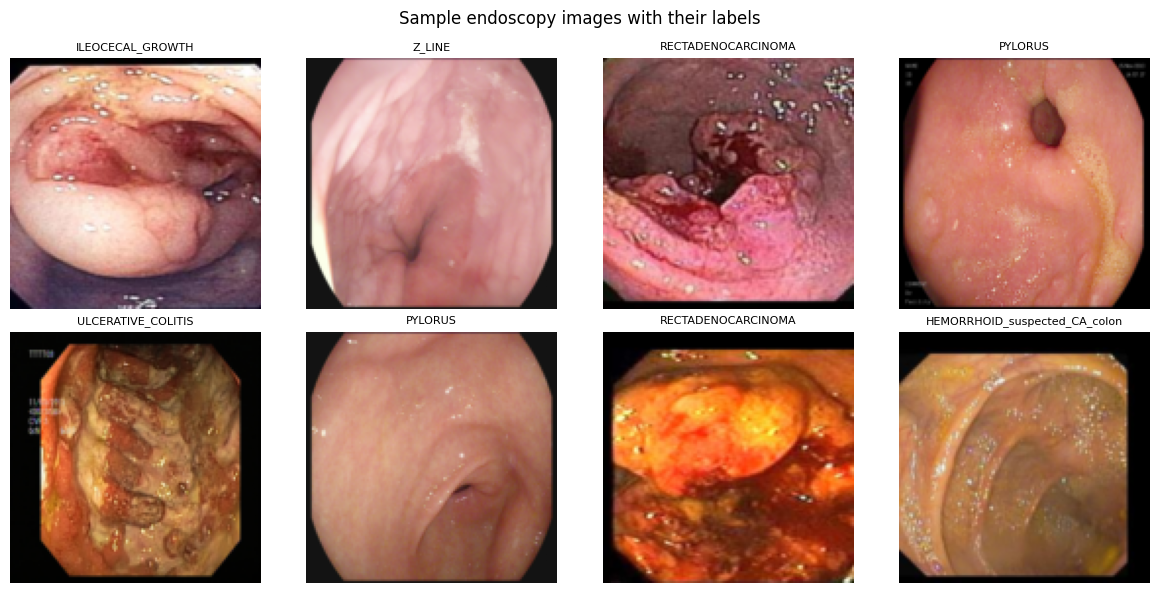

In [ ]:
# ============================================================
# 5b. VISUALIZE ONE BATCH OF TRAINING IMAGES
# ============================================================

images, labels = next(iter(train_loader))     # grab the first batch

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    # tensor shape is [C, H, W]; matplotlib wants [H, W, C]
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(class_names[labels[i]], fontsize=8)
    plt.axis("off")
plt.suptitle("Sample endoscopy images with their labels")
plt.tight_layout()
plt.show()


## 6. Build the CNN from Scratch — and understand its parts

A CNN has two jobs:

**A) The feature extractor (convolution + pooling)** — finds patterns in the image.

- A **filter** (kernel) is a tiny `3 × 3` grid of numbers that slides across the image looking for one pattern — an edge, a blood vessel, a polyp boundary, a texture of inflamed tissue. Each filter produces a **feature map** showing *where* that pattern appears.
- A **convolution layer** is a stack of many such filters. Our first layer has **16 filters**; deeper layers (32, then 64 filters) combine simple patterns into more complex ones.
- **Pooling** (`MaxPool2d`) shrinks each feature map by half, keeping the strongest signals — faster, and a little robust to small shifts.

**B) The classification head (fully-connected layers)** — makes the final decision.

- We **flatten** the feature maps into one long vector.
- Two **Linear** layers turn that vector into **14 scores** — one per class. The biggest score wins.

The whole flow for a `128 × 128` image:

```
Image 3×128×128
  → Conv(16 filters) → ReLU → Pool   →  16×64×64
  → Conv(32 filters) → ReLU → Pool   →  32×32×32
  → Conv(64 filters) → ReLU → Pool   →  64×16×16
  → Flatten          →  16384 numbers
  → Dropout (Round 2 only)
  → Linear → ReLU    →  128 numbers
  → Linear           →  14 numbers (one score per class)
```

*(ReLU replaces negative numbers with 0 — it lets the network learn non-straight-line patterns.)*

The model takes `p_dropout` as an argument so we can train the **same architecture** with dropout OFF (Round 1) and ON (Round 2) — a fair comparison.

In [ ]:
# ============================================================
# 6. THE CNN MODEL (BUILT FROM SCRATCH)
# ============================================================

NUM_CLASSES = 14    # the 14 endoscopy classes of CRCCD_V1

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, p_dropout=0.0):
        super().__init__()
        # --- Feature extractor: 3 convolution layers ---
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3 -> 16 filters
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 -> 32 filters
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 -> 64 filters
        self.pool  = nn.MaxPool2d(2, 2)                           # halves height and width

        # --- Classification head ---
        self.dropout = nn.Dropout(p_dropout)          # OFF (p=0.0) in Round 1, ON (p=0.5) in Round 2
        self.fc1 = nn.Linear(64 * 16 * 16, 128)       # flattened 64x16x16 features -> 128 neurons
        self.fc2 = nn.Linear(128, num_classes)        # 128 -> one score per class

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 128 -> 64
        x = self.pool(F.relu(self.conv2(x)))   # 64  -> 32
        x = self.pool(F.relu(self.conv3(x)))   # 32  -> 16
        x = torch.flatten(x, 1)                # one long vector per image
        x = self.dropout(x)                    # randomly zero some features (training only)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)                        # raw scores (logits), one per class
        return x

# Build the Round 1 model: NO dropout (p_dropout = 0.0)
model = SimpleCNN(p_dropout=0.0).to(device)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=14, bias=True)
)

Total trainable parameters: 2,122,670


## 7. Training and Validation Functions

**The training loop, in plain words:**

1. Show the model a batch of images.
2. It guesses the class → we measure how wrong it is with a **loss** (`CrossEntropyLoss`).
3. **Backpropagation** figures out how to nudge every weight to be less wrong.
4. The **optimizer** (`Adam`) applies those nudges.
5. Repeat for the whole training set = **1 epoch**. Then check accuracy on the validation set (no learning there — just measuring).

- **Loss** = how wrong the model is (lower is better).
- **Accuracy** = fraction of images labelled correctly (higher is better).

We record loss and accuracy for **both** the train and validation sets every epoch, so we can plot the curves and *see* overfitting.


In [ ]:
# ============================================================
# 7. TRAINING / VALIDATION LOOP
# ============================================================

def train_model(model, train_loader, val_loader, epochs, lr=LR):
    """Trains 'model' and returns a history dict with the four curves
    (train loss, val loss, train accuracy, val accuracy) per epoch."""

    criterion = nn.CrossEntropyLoss()                        # loss for multi-class classification
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # Adam optimizer

    # We record these each epoch so we can plot the curves afterwards
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        # ---------------- TRAINING PHASE ----------------
        model.train()                                # enable training mode (dropout ON)
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()                    # reset gradients from the previous step
            outputs = model(imgs)                    # forward pass -> class scores
            loss = criterion(outputs, labels)        # how wrong are we?
            loss.backward()                          # backpropagation
            optimizer.step()                         # update the weights

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total   += labels.size(0)
        train_loss = running_loss / total
        train_acc  = correct / total

        # ---------------- VALIDATION PHASE ----------------
        model.eval()                                 # evaluation mode (dropout OFF)
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():                        # no learning here, just checking
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total   += labels.size(0)
        val_loss = running_loss / total
        val_acc  = correct / total

        # Save this epoch's numbers for plotting later
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs}  "
              f"train_loss={train_loss:.3f} train_acc={train_acc:.3f}  |  "
              f"val_loss={val_loss:.3f} val_acc={val_acc:.3f}")

    return history


## 8. Train Round 1 (no augmentation, no dropout)

We expect this model to **overfit**: training accuracy will keep climbing while test accuracy stalls.

In [ ]:
# ============================================================
# 8. TRAIN ROUND 1 - EXPECT OVERFITTING
# ============================================================

history_plain = train_model(model, train_loader, val_loader, epochs=EPOCHS_R1)


Epoch  1/15  train_loss=1.650 train_acc=0.394  |  val_loss=1.319 val_acc=0.519
Epoch  2/15  train_loss=1.117 train_acc=0.587  |  val_loss=0.939 val_acc=0.678
Epoch  3/15  train_loss=0.887 train_acc=0.678  |  val_loss=0.887 val_acc=0.688
Epoch  4/15  train_loss=0.709 train_acc=0.737  |  val_loss=0.676 val_acc=0.774
Epoch  5/15  train_loss=0.546 train_acc=0.801  |  val_loss=0.621 val_acc=0.790
Epoch  6/15  train_loss=0.420 train_acc=0.842  |  val_loss=0.565 val_acc=0.829
Epoch  7/15  train_loss=0.353 train_acc=0.869  |  val_loss=0.617 val_acc=0.817
Epoch  8/15  train_loss=0.270 train_acc=0.899  |  val_loss=0.609 val_acc=0.821
Epoch  9/15  train_loss=0.219 train_acc=0.920  |  val_loss=0.693 val_acc=0.823
Epoch 10/15  train_loss=0.193 train_acc=0.925  |  val_loss=0.693 val_acc=0.815
Epoch 11/15  train_loss=0.138 train_acc=0.950  |  val_loss=0.828 val_acc=0.810
Epoch 12/15  train_loss=0.158 train_acc=0.938  |  val_loss=0.647 val_acc=0.857
Epoch 13/15  train_loss=0.129 train_acc=0.953  |  va

### Plot the Round 1 loss and accuracy curves

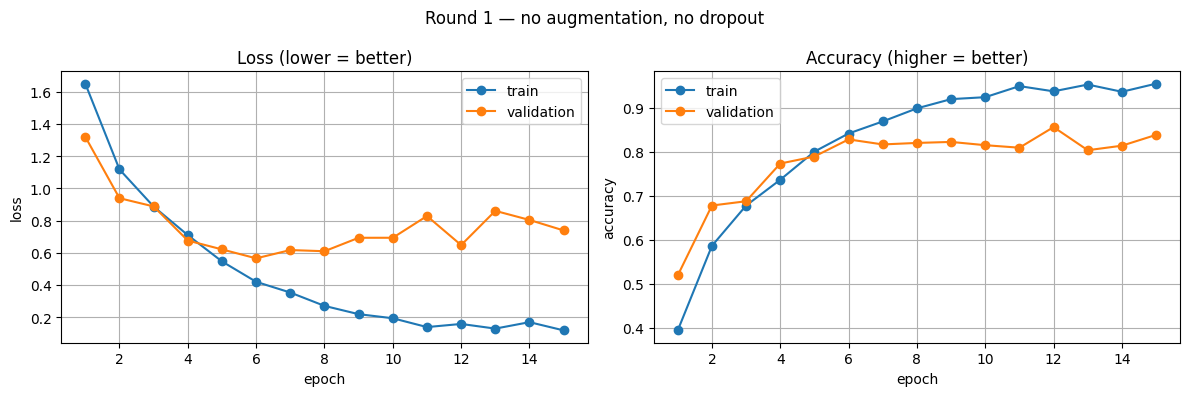

In [ ]:
# ============================================================
# HELPER: PLOT TRAINING vs VALIDATION CURVES
# ============================================================

def plot_history(history, title=""):
    """Draws the loss curves (left) and accuracy curves (right)
    for training vs validation - the key evidence for overfitting analysis."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # ---- Loss curves ----
    ax1.plot(epochs, history["train_loss"], "o-", label="train")
    ax1.plot(epochs, history["val_loss"],   "o-", label="validation")
    ax1.set_title("Loss (lower = better)")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(True)

    # ---- Accuracy curves ----
    ax2.plot(epochs, history["train_acc"], "o-", label="train")
    ax2.plot(epochs, history["val_acc"],   "o-", label="validation")
    ax2.set_title("Accuracy (higher = better)")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_plain, "Round 1 — no augmentation, no dropout")


### 🔍 Spot the overfitting (Round 1 analysis)

Read the two curves above like this:

- **Training accuracy keeps climbing** and **training loss keeps dropping** — the model fits the training images better and better.
- **Validation accuracy stalls** and **validation loss stops improving (or creeps back up)**.

That growing **gap between the train and validation curves** is **overfitting**: the model is *memorizing* the exact training images (their backgrounds, brightness, positioning) instead of learning general class features. On new, unseen images it performs worse.

**Why does it happen here?** A limited dataset + a model with plenty of parameters + no variety in the images = easy memorization.

In the next section we fix this with **data augmentation (transforms)** and **dropout**.


## 9. Round 2 — Fix the Overfitting: **Data Augmentation + Dropout**

We attack the memorization in two simple ways (exactly what the midterm asks for):

**1) Data augmentation (simple data transformations).** Each time the model sees a training image, we randomly change it a little. The model effectively sees a *fresh variation* of every image each epoch, so it cannot memorize exact pictures — it must learn the real class features.

> **Important:** augmentation is applied **only to the training set**. The validation set stays clean, because we want to measure performance on *normal* images.

**2) Dropout (p = 0.5).** During training, dropout randomly switches off half the neurons in the classification head at every step. This prevents the network from relying too much on any single feature, so it generalizes better.

Everything else (architecture, optimizer, image size, batch size) stays **the same** — this makes it a fair comparison against Round 1.

**Which augmentations for endoscopy images?** Unlike X-rays, endoscopy images have **no fixed orientation** — the camera rotates freely inside the body. So flips and rotations are very realistic here:

- **RandomHorizontalFlip** — mirror images are equally valid.
- **RandomRotation(15°)** — the camera angle varies.
- **ColorJitter (brightness/contrast/saturation)** — different lighting conditions of the endoscope.

In [ ]:
# ============================================================
# 9. ROUND 2 DATA PIPELINE (AUGMENTATION FOR TRAINING ONLY)
# ============================================================

# --- Training transform WITH augmentation ---
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),                     # mirror left-right (realistic for endoscopy)
    transforms.RandomRotation(15),                         # small camera-angle rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # lighting variation
    transforms.ToTensor(),
])

# --- Validation/Test transform stays basic (NO augmentation!) ---
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds_aug = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds_clean = datasets.ImageFolder(TEST_DIR,  transform=val_transform)

train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True)
val_loader_clean = DataLoader(val_ds_clean, batch_size=BATCH_SIZE, shuffle=False)

print("Augmented training pipeline ready.")


Augmented training pipeline ready.


### Augmentation preview

The **same** endoscopy image fetched 5 times — each fetch re-applies the random transforms, so the model never sees the exact same picture twice.

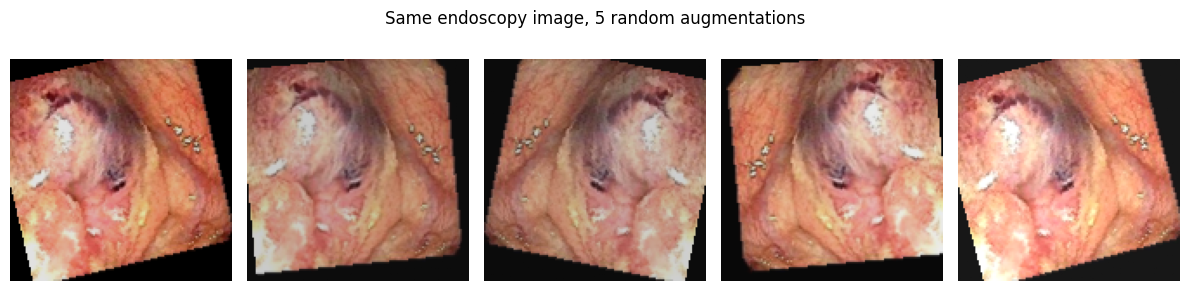

In [ ]:
# ============================================================
# 9b. SAME IMAGE, 5 RANDOM AUGMENTATIONS
# ============================================================

plt.figure(figsize=(12, 3))
for i in range(5):
    aug_img, _ = train_ds_aug[0]     # re-fetching re-applies the random transforms
    plt.subplot(1, 5, i + 1)
    plt.imshow(aug_img.permute(1, 2, 0))
    plt.axis("off")
plt.suptitle("Same endoscopy image, 5 random augmentations")
plt.tight_layout()
plt.show()


### Train Round 2 (augmentation + dropout p=0.5)

A **fresh** model with the same architecture — now with dropout ON — trained on the augmented data.

Epoch  1/30  train_loss=1.820 train_acc=0.331  |  val_loss=1.427 val_acc=0.474
Epoch  2/30  train_loss=1.361 train_acc=0.487  |  val_loss=1.173 val_acc=0.620
Epoch  3/30  train_loss=1.187 train_acc=0.563  |  val_loss=1.082 val_acc=0.629
Epoch  4/30  train_loss=1.058 train_acc=0.608  |  val_loss=0.937 val_acc=0.683
Epoch  5/30  train_loss=0.983 train_acc=0.632  |  val_loss=0.947 val_acc=0.659
Epoch  6/30  train_loss=0.893 train_acc=0.663  |  val_loss=0.853 val_acc=0.705
Epoch  7/30  train_loss=0.824 train_acc=0.692  |  val_loss=0.699 val_acc=0.772
Epoch  8/30  train_loss=0.774 train_acc=0.710  |  val_loss=0.687 val_acc=0.781
Epoch  9/30  train_loss=0.704 train_acc=0.741  |  val_loss=0.654 val_acc=0.783
Epoch 10/30  train_loss=0.718 train_acc=0.733  |  val_loss=0.655 val_acc=0.778
Epoch 11/30  train_loss=0.634 train_acc=0.760  |  val_loss=0.628 val_acc=0.790
Epoch 12/30  train_loss=0.627 train_acc=0.768  |  val_loss=0.575 val_acc=0.808
Epoch 13/30  train_loss=0.591 train_acc=0.780  |  va

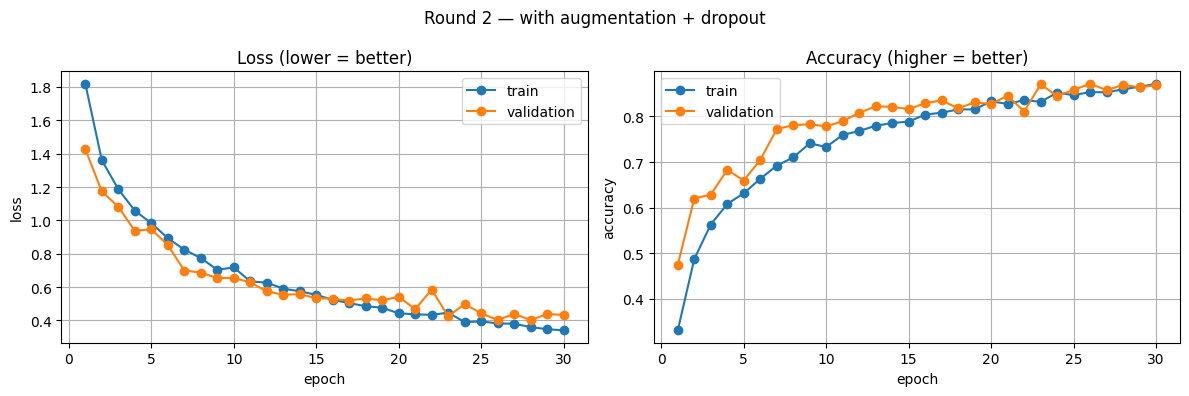

In [ ]:
# ============================================================
# 9c. TRAIN ROUND 2 - OVERFITTING SHOULD BE CONTROLLED
# ============================================================

model_aug = SimpleCNN(p_dropout=0.5).to(device)   # same architecture, dropout ON

history_aug = train_model(model_aug, train_loader_aug, val_loader_clean, epochs=EPOCHS_R2)
plot_history(history_aug, "Round 2 — with augmentation + dropout")


## 10. Compare Round 1 vs Round 2 — Evidence That Overfitting Is Controlled

We now put the two experiments side by side. Look for these three pieces of evidence:

1. **The train–validation gap shrinks** in Round 2 (the curves stay close together).
2. **Validation loss no longer explodes upward** in Round 2.
3. **Validation accuracy is higher and steadier** in Round 2.


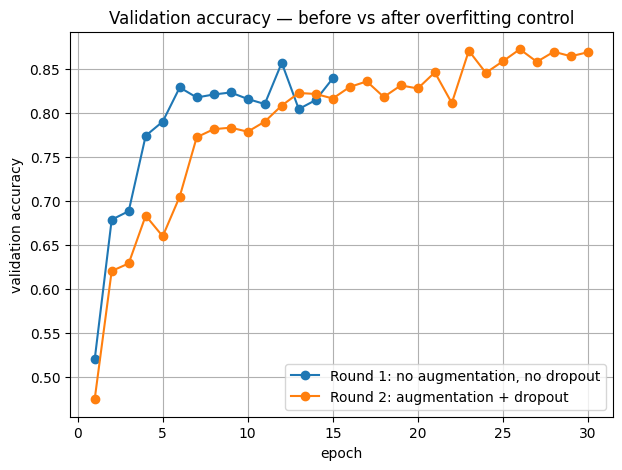

================ Overfitting evidence ================
Best val accuracy   (Round 1): 0.857
Best val accuracy   (Round 2): 0.872
Final train-val gap (Round 1): 0.116   <-- large gap = overfitting
Final train-val gap (Round 2): 0.003   <-- small gap = controlled
Final val loss      (Round 1): 0.738
Final val loss      (Round 2): 0.433


In [ ]:
# ============================================================
# 10. ROUND 1 vs ROUND 2 COMPARISON
# ============================================================

# ---- Validation accuracy of both rounds on one plot ----
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(history_plain["val_acc"]) + 1), history_plain["val_acc"],
         "o-", label="Round 1: no augmentation, no dropout")
plt.plot(range(1, len(history_aug["val_acc"]) + 1), history_aug["val_acc"],
         "o-", label="Round 2: augmentation + dropout")
plt.title("Validation accuracy — before vs after overfitting control")
plt.xlabel("epoch"); plt.ylabel("validation accuracy")
plt.legend(); plt.grid(True)
plt.show()

# ---- Numerical evidence table ----
gap1 = history_plain["train_acc"][-1] - history_plain["val_acc"][-1]   # final train-val gap, Round 1
gap2 = history_aug["train_acc"][-1]   - history_aug["val_acc"][-1]     # final train-val gap, Round 2

print("================ Overfitting evidence ================")
print(f"Best val accuracy   (Round 1): {max(history_plain['val_acc']):.3f}")
print(f"Best val accuracy   (Round 2): {max(history_aug['val_acc']):.3f}")
print(f"Final train-val gap (Round 1): {gap1:.3f}   <-- large gap = overfitting")
print(f"Final train-val gap (Round 2): {gap2:.3f}   <-- small gap = controlled")
print(f"Final val loss      (Round 1): {history_plain['val_loss'][-1]:.3f}")
print(f"Final val loss      (Round 2): {history_aug['val_loss'][-1]:.3f}")


## 11. Final Evaluation — Confusion Matrix and Classification Report

The **confusion matrix** shows, for every true class, how many images were predicted as each class — the diagonal is correct predictions, everything off-diagonal is a mistake. With 14 classes, the matrix also reveals *which classes get confused with each other* (e.g. visually similar tissue types). The **classification report** gives per-class precision, recall and F1-score.

In [ ]:
# ============================================================
# 11a. COLLECT PREDICTIONS ON THE TEST SET
# ============================================================

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader):
    """Runs the model on every batch in 'loader' and returns
    (predicted labels, true labels) as numpy arrays."""
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            preds.append(outputs.argmax(1).cpu())    # class with the highest score
            targets.append(labels)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

# Evaluate the FINAL (Round 2) model on the clean test set
y_pred, y_true = get_predictions(model_aug, val_loader)
print("Total test images evaluated:", len(y_true))


Total test images evaluated: 1750


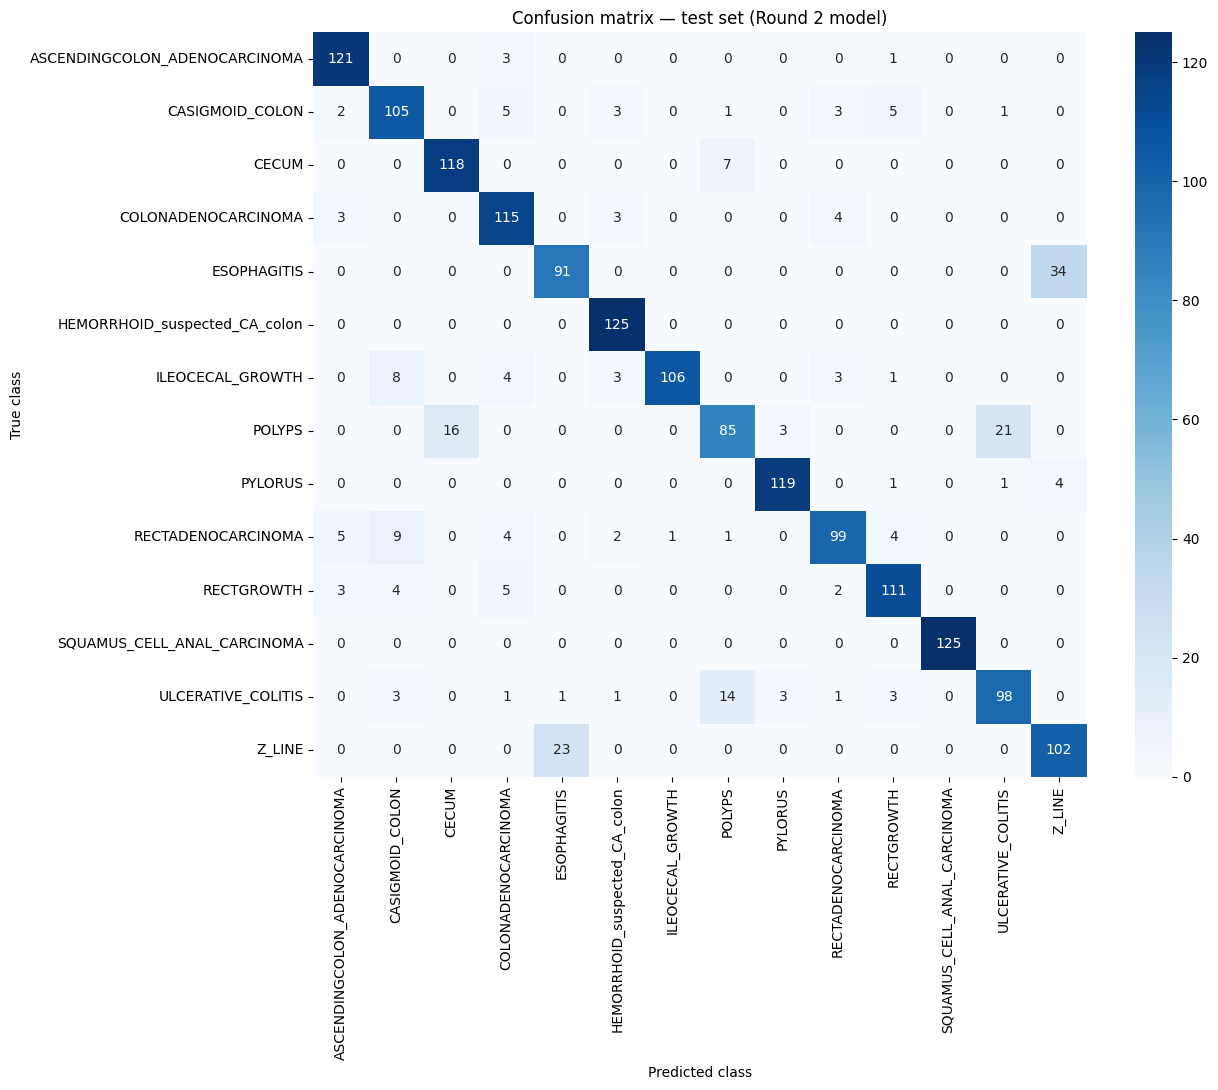

                               precision    recall  f1-score   support

ASCENDINGCOLON_ADENOCARCINOMA       0.90      0.97      0.93       125
              CASIGMOID_COLON       0.81      0.84      0.83       125
                        CECUM       0.88      0.94      0.91       125
          COLONADENOCARCINOMA       0.84      0.92      0.88       125
                  ESOPHAGITIS       0.79      0.73      0.76       125
HEMORRHOID_suspected_CA_colon       0.91      1.00      0.95       125
             ILEOCECAL_GROWTH       0.99      0.85      0.91       125
                       POLYPS       0.79      0.68      0.73       125
                      PYLORUS       0.95      0.95      0.95       125
           RECTADENOCARCINOMA       0.88      0.79      0.84       125
                   RECTGROWTH       0.88      0.89      0.88       125
  SQUAMUS_CELL_ANAL_CARCINOMA       1.00      1.00      1.00       125
           ULCERATIVE_COLITIS       0.81      0.78      0.80       125
     

In [ ]:
# ============================================================
# 11b. CONFUSION MATRIX + CLASSIFICATION REPORT (14 CLASSES)
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(13, 11))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Confusion matrix — test set (Round 2 model)")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Per-class precision, recall, F1-score
print(classification_report(y_true, y_pred, target_names=class_names))


### Misclassified samples

Looking at the mistakes tells us *why* the model fails — visually similar tissue classes are the hardest to separate.

Total misclassified test samples: 230


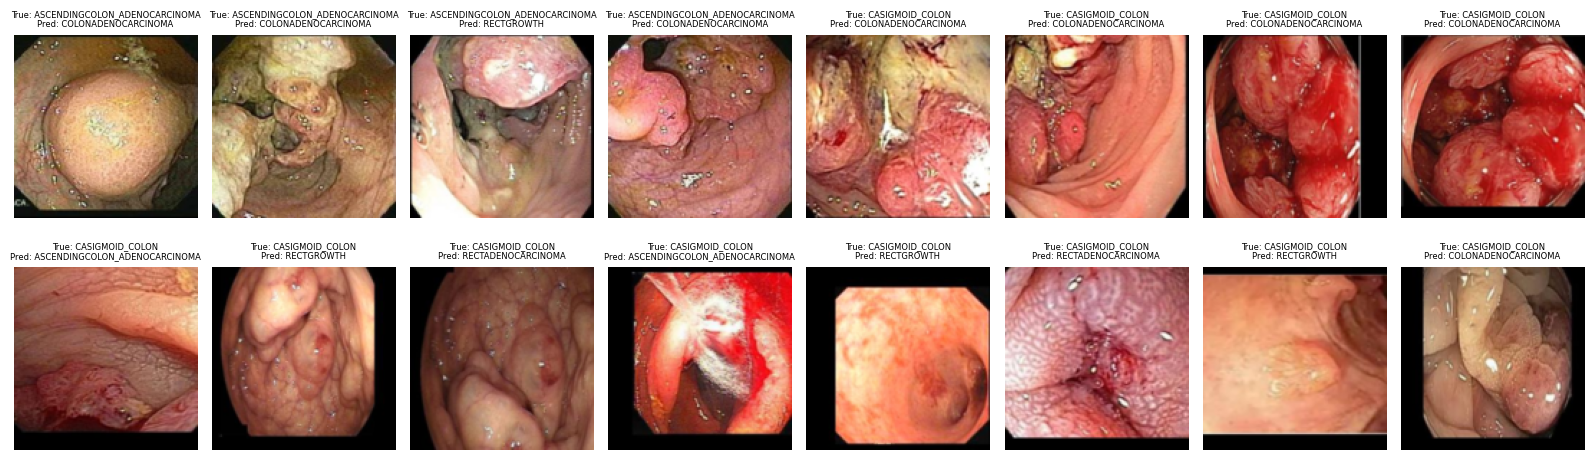

In [ ]:
# ============================================================
# 11c. SHOW MISCLASSIFIED TEST IMAGES
# ============================================================

model_aug.eval()
misclassified = []                       # will hold (image, true label, predicted label)

with torch.no_grad():
    for imgs, labels in val_loader_clean:
        imgs_dev = imgs.to(device)
        preds = model_aug(imgs_dev).argmax(1).cpu()
        for img, true, pred in zip(imgs, labels, preds):
            if true != pred:             # keep only the mistakes
                misclassified.append((img, true.item(), pred.item()))

print(f"Total misclassified test samples: {len(misclassified)}")

# Show up to 16 mistakes in a 2x8 grid
num_to_show = min(16, len(misclassified))
plt.figure(figsize=(16, 5))
for idx in range(num_to_show):
    img, true, pred = misclassified[idx]
    plt.subplot(2, 8, idx + 1)
    plt.imshow(img.permute(1, 2, 0))
    plt.title(f"True: {class_names[true]}\nPred: {class_names[pred]}", fontsize=6)
    plt.axis("off")
plt.tight_layout()
plt.show()


## 12. Visualize the Learned Filters and Feature Maps 👀

Two useful things to look at inside the trained (Round 2) CNN:

1. **The filters themselves** — the actual `3 × 3` weight grids of the first convolution layer. They tend to become **edge / texture detectors**.
2. **Feature maps** — the *response* of those filters to a real image: bright spots show *where* each pattern was found.


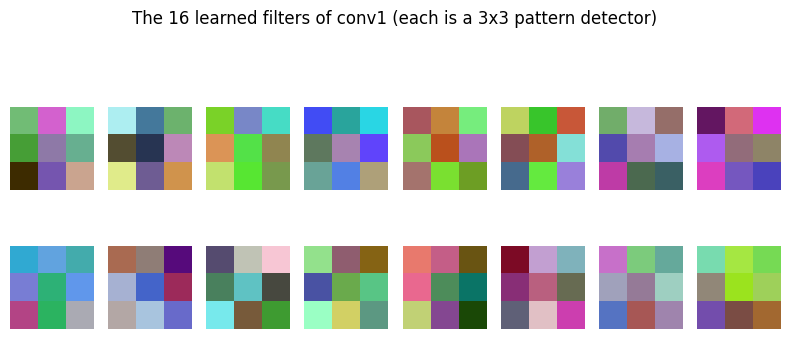

In [ ]:
# ============================================================
# 12a. THE 16 LEARNED FILTERS OF conv1
# ============================================================

weights = model_aug.conv1.weight.data.clone().cpu()   # shape: [16, 3, 3, 3]

# Scale weights to [0, 1] so we can display them as tiny colour images
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min + 1e-8)

plt.figure(figsize=(8, 4))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(weights[i].permute(1, 2, 0))           # [3,3,3] shown as a small RGB patch
    plt.axis("off")
plt.suptitle("The 16 learned filters of conv1 (each is a 3x3 pattern detector)")
plt.tight_layout()
plt.show()


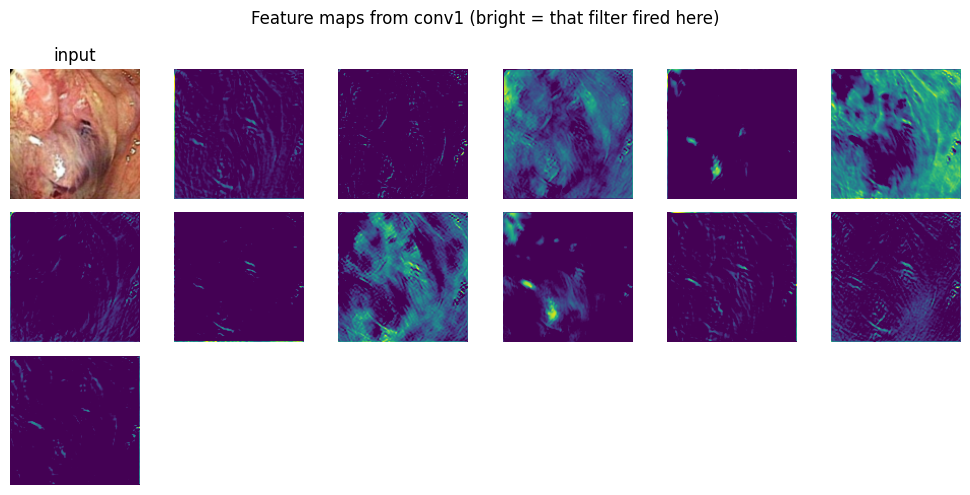

In [ ]:
# ============================================================
# 12b. FEATURE MAPS: HOW conv1 RESPONDS TO ONE REAL IMAGE
# ============================================================

img, label = val_ds_clean[0]                         # take one validation image
img_batch = img.unsqueeze(0).to(device)        # add the batch dimension: [1, 3, H, W]

model_aug.eval()
with torch.no_grad():
    feature_maps = F.relu(model_aug.conv1(img_batch)).cpu()[0]   # shape: [16, 128, 128]

plt.figure(figsize=(10, 5))
# original input image first
plt.subplot(3, 6, 1)
plt.imshow(img.permute(1, 2, 0)); plt.title("input"); plt.axis("off")
# then the first 12 feature maps
for i in range(12):
    plt.subplot(3, 6, i + 2)
    plt.imshow(feature_maps[i], cmap="viridis")
    plt.axis("off")
plt.suptitle("Feature maps from conv1 (bright = that filter fired here)")
plt.tight_layout()
plt.show()


## 13. Conclusion — Recap

| Concept | What we did / observed |
|---|---|
| **Dataset** | 8,750 endoscopy images, 14 balanced classes (CRCCD_V1) |
| **Split** | Predefined by the dataset authors: 7,000 train / 1,750 test |
| **Model** | Basic 3-conv-layer CNN built from scratch (~2.1M parameters) |
| **Round 1** | No augmentation, no dropout → train accuracy ≈ high, test stalls → **overfitting** |
| **Round 2** | Flip + rotation + colour jitter + dropout 0.5 → **train/test curves stay close** |
| **Evidence** | Smaller train–test gap, stable test loss, higher & steadier test accuracy, 14×14 confusion matrix + classification report |

**The big takeaway:** even with 7,000 training images, a 14-class problem gives each class only 500 examples — easy for a CNN to *memorize*. **Simple data transformations (augmentation)** and **dropout** force it to *generalize* — and the training vs validation curves are the clear evidence that overfitting has been controlled, exactly as the midterm requires.